# Live NBA Game Outcome Prediction
This project aims to predict the outcome of an NBA game. It utilizes both historical and real-time data. Crucial data points include score, home court advantage, time remaining, and more as I plan to display a live probability of the possible outcomes with a logistic regression model that is trained with over 3 million basketball plays.

## 1. Imports & Functions

In [1]:
from config import data_dir, results_dir
from load import load_playbyplay, espn_scores
from process import process_playbyplay
from analyze import (
    show_correlations,
    train_model,
    predict_win_probability,
    plot_correlation_heatmap,
    plot_win_rate_by_quarter,
    plot_win_prob_vs_margin,
    plot_home_away_wins
)

## 2. Load Data
Load all 6 seasons of NBA play-by-play data from Kaggle CSVs and combine them into one.

In [2]:
pbp_raw = load_playbyplay()
print(f"Total plays loaded: {len(pbp_raw):,}") #total number of plays recorded from 2015-2021

Loaded: NBA_PBP_2017-18.csv — 590868 rows
Loaded: NBA_PBP_2019-20.csv — 539265 rows
Loaded: NBA_PBP_2016-17.csv — 596645 rows
Loaded: NBA_PBP_2018-19.csv — 614516 rows
Loaded: NBA_PBP_2020-21.csv — 97673 rows
Loaded: NBA_PBP_2015-16.csv — 601557 rows

All seasons combined: 3040524 total rows
Total plays loaded: 3,040,524


## 3. Process/Clean Data
Keep only the needed columns, create a score margin column (home-away), calculate total seconds left in the game, and create the main variable (HomeWin).

In [3]:
pbp = process_playbyplay(pbp_raw)
print("\nPrint 5 rows from start of game")
pbp.head()

Play-by-play processed: 3040524 rows remaining

Print 5 rows from start of game


,WinningTeam,AwayTeam,HomeTeam,AwayScore,HomeScore,Quarter,SecLeft,Date,Location,ScoreMargin,TotalSecLeft,HomeWin
0,CLE,BOS,CLE,0,0,1,720,October 17 2017,Quicken Loans Arena Cleveland Ohio,0,2880,1
1,CLE,BOS,CLE,2,0,1,704,October 17 2017,Quicken Loans Arena Cleveland Ohio,-2,2864,1
2,CLE,BOS,CLE,2,0,1,687,October 17 2017,Quicken Loans Arena Cleveland Ohio,-2,2847,1
3,CLE,BOS,CLE,2,0,1,683,October 17 2017,Quicken Loans Arena Cleveland Ohio,-2,2843,1
4,CLE,BOS,CLE,2,0,1,681,October 17 2017,Quicken Loans Arena Cleveland Ohio,-2,2841,1


In [4]:
# Confirm that there are no missing values
print("Missing values per column:")
print(pbp.isnull().sum())

Missing values per column:
WinningTeam     0
AwayTeam        0
HomeTeam        0
AwayScore       0
HomeScore       0
Quarter         0
SecLeft         0
Date            0
Location        0
ScoreMargin     0
TotalSecLeft    0
HomeWin         0
dtype: int64


## 4. Correlational Analysis
Look at how strongly each variable correlates to the outcome before modeling. Score margin has a strong correlation (0.52) while time remaining has a very weak correlation. The two variables together though end up showing more

In [5]:
show_correlations(pbp) #showing basic correlations


Correlations with HomeWin:
              ScoreMargin  TotalSecLeft   HomeWin
ScoreMargin      1.000000     -0.057848  0.525159
TotalSecLeft    -0.057848      1.000000  0.001812
HomeWin          0.525159      0.001812  1.000000


## 5. Win Rate by Quarter
Unsuprisingly, being up later in the game reveals a higher likelihood of winning.

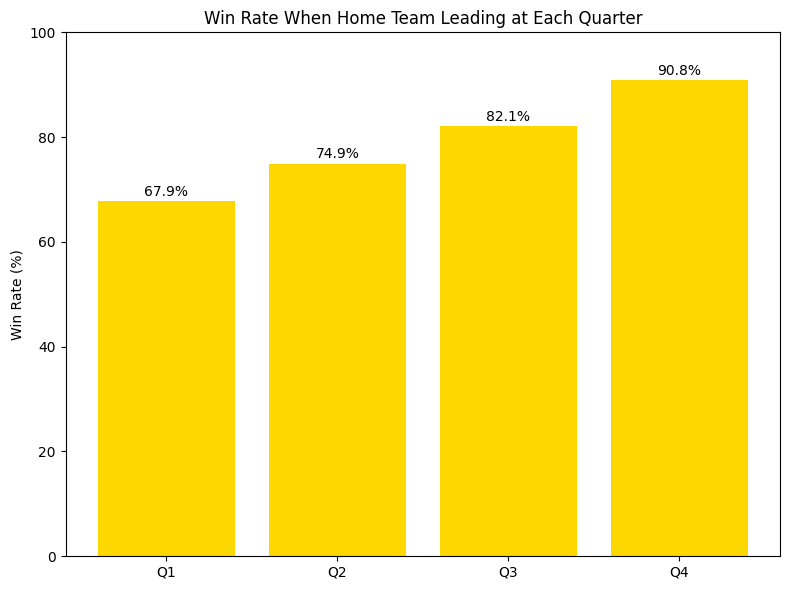

Saved: win_rate_by_quarter.png


In [6]:
plot_win_rate_by_quarter(pbp) #showing win rates at the start of each quarter from home team perspective

## 6. Home vs Away Wins
Home teams win about 58% of the time.

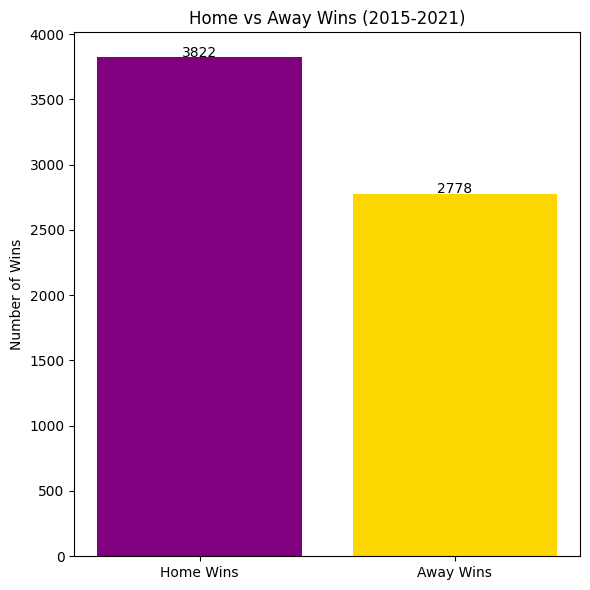

Saved: home_away_wins.png


In [7]:
plot_home_away_wins(pbp) #Simple bar chart showing home team winning vs. away team winning

## 7. Train the Model
Trying to train a logistic regression model using score margin and time remaining as features.

In [8]:
model = train_model(pbp) 


Model Accuracy: 74.22%


## 8. Win Probability and Score Margin
This chart shows how win probability changes as the score margin changes, halfway through the third quarter.

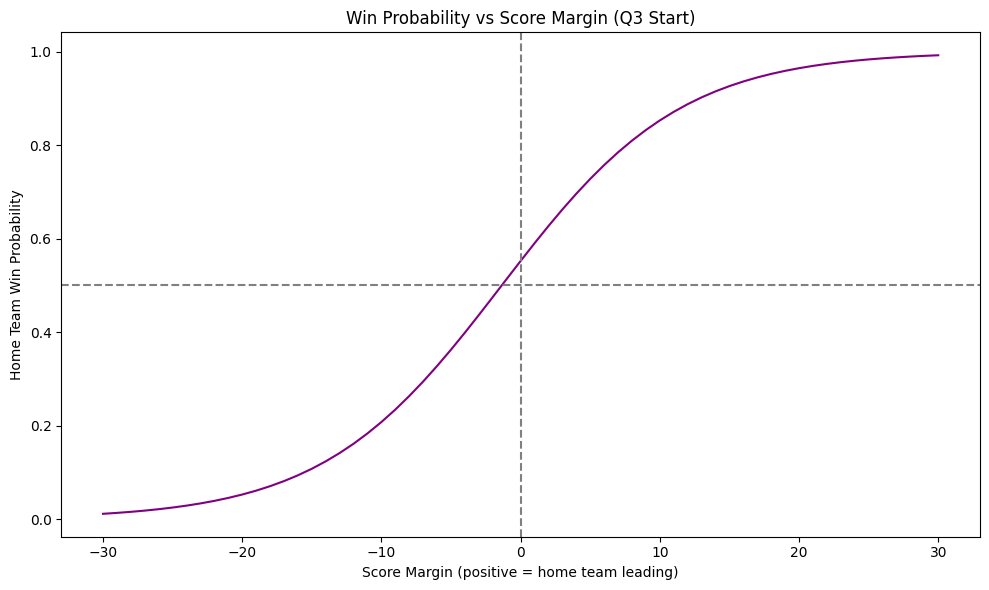

Saved: win_prob_vs_margin.png


In [9]:
plot_win_prob_vs_margin(model)

## 9. Correlation Heatmap

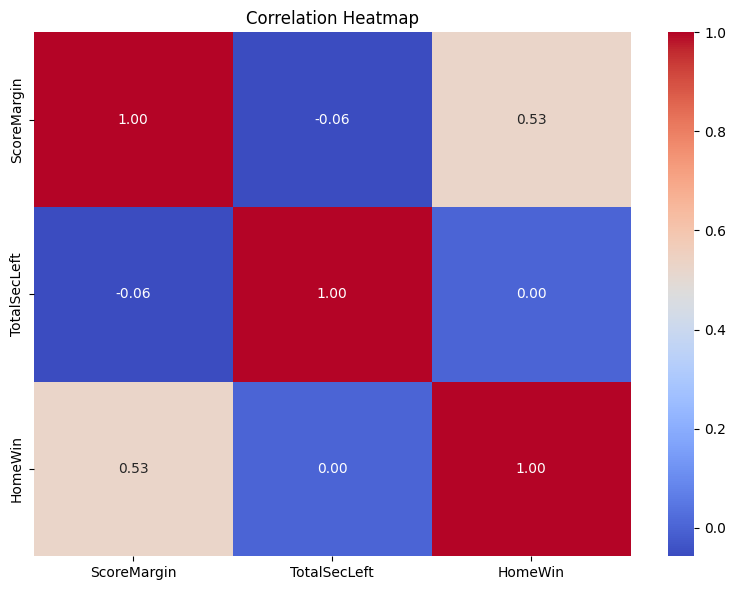

Saved: correlation_heatmap.png


In [10]:
plot_correlation_heatmap(pbp) #creating heatmap with variables scoremargin, homewin, and totalsecleft

## 10. Testing Predictions
Given random game situations, the model outputs a win probability for the home team with some tighter than others.

In [11]:
situations = [
  # first number represents margin of home team over away, with the second number representing time left in game in seconds)
    (10, 720, 'Start of 3rd quarter, I expect it should heavily sway home team wins | model probability ',), 
    (0,60,'Game tied with a min left, I expect it should lean slighty for home team | model probability',),
    (-15, 1440,'Home team down 15 at half, I expect it should be heavy underdogs | model probability ',), 
    (3, 30,'Home team up 3 with 30 secs left in game, I expect it should be moderate home team win | model probability',), 
]

for margin, secs, description in situations:
    prob = predict_win_probability(model, margin, secs)
    print(f"{description}: {prob:.2%}")

Start of 3rd quarter, I expect it should heavily sway home team wins | model probability : 85.29%
Game tied with a min left, I expect it should lean slighty for home team | model probability: 54.45%
Home team down 15 at half, I expect it should be heavy underdogs | model probability : 11.15%
Home team up 3 with 30 secs left in game, I expect it should be moderate home team win | model probability: 65.50%


## 11. Live prediction with known ESPN play-by-play data
 Given ESPN play-by-play data from Lakers vs. Timberwolves, the model outputs a win probability for the home team again.


In [12]:
url = 'https://site.api.espn.com/apis/site/v2/sports/basketball/nba/summary?event=401810801'
plays = espn_scores(url)
for play in plays[:20]: #only showing first 20 plays
  margin = play['margin']
  secs = play['secs']
  description = play['description']
  prob = predict_win_probability(model, margin, secs)
  print(f" {description}: {prob:.2%}")


 Home team has 0 and away team has 0 with 12:00 left in quarter 1: 57.83%
 Home team has 0 and away team has 0 with 11:42 left in quarter 1: 57.81%
 Home team has 0 and away team has 0 with 11:40 left in quarter 1: 57.80%
 Home team has 0 and away team has 0 with 11:21 left in quarter 1: 57.78%
 Home team has 0 and away team has 0 with 11:19 left in quarter 1: 57.78%
 Home team has 0 and away team has 0 with 11:15 left in quarter 1: 57.77%
 Home team has 0 and away team has 0 with 11:11 left in quarter 1: 57.77%
 Home team has 0 and away team has 0 with 10:59 left in quarter 1: 57.75%
 Home team has 0 and away team has 0 with 10:50 left in quarter 1: 57.74%
 Home team has 0 and away team has 0 with 10:47 left in quarter 1: 57.74%
 Home team has 0 and away team has 0 with 10:40 left in quarter 1: 57.73%
 Home team has 0 and away team has 0 with 10:35 left in quarter 1: 57.73%
 Home team has 0 and away team has 2 with 10:27 left in quarter 1: 50.04%
 Home team has 0 and away team has 2 w